In [1]:
import sys, os
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable (if running from parameter_scan/)
sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('.'))

from xso.parscans import run_xso_parscan, run_xso_stabilityscan

#from cariaco_ssm_setup import model, model_setup, model_setup_slim, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets
from parscan_utils import (
    compute_cost_grid, find_best_fit, get_default_from_setup,
)

from taniguchi_setup import model, model_setup

In [2]:
with model:
    output = model_setup.xsimlab.run()

Text(0, 0.5, 'ESD [µm]')

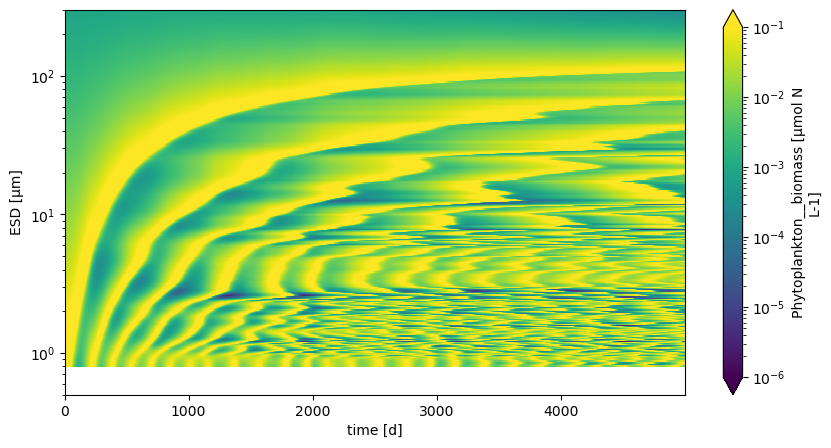

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(10, 5))
output.Phytoplankton__biomass.where(output.Phytoplankton__biomass > 0).plot(
    x='time', y='phyto', ax=ax,
    norm=mcolors.LogNorm(vmin=1e-6, vmax=0.1),
    cmap='viridis')
ax.set_yscale('log')
ax.set_ylim(0.5, 300)        # crop to alive range (s_max ≈ 175 µm at N_T=15)
ax.set_ylabel('ESD [µm]')

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../model'))

from cariaco_ssm_comps import MonodGrowth_SizeBased

MonodGrowth_SizeBased.fluxes.uptake(resource=1,consumer=1, halfsat=0.5, mu_max=1)

0.6666666666666666

In [2]:
# -----------------------------------------------------------------------------
# Load observations
# -----------------------------------------------------------------------------
obs_vec, labels, bin_defs, monthly_df, forcings = load_cariaco_targets(regime='all')
print("Observation targets:")
for lab, val in zip(labels, obs_vec):
    print(f"  {lab:20s}: {val:.5f}")

# -----------------------------------------------------------------------------
# Tiny 2D scan: 3 x 3 = 9 runs on KsZ × fish_rate
# -----------------------------------------------------------------------------
p1_name = 'Grazing__KsZ'
p2_name = 'FishGrazing__rate'
p1_values = np.linspace(0.5, 3.0, 3)
p2_values = np.linspace(0.001, 0.01, 3)

print(f"\nRunning 3x3 scan on {p1_name} x {p2_name} ...")
scan_results = run_xso_parscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup',
    param_name=p1_name,
    param_values=p1_values,
    param_name2=p2_name,
    param_values2=p2_values,
    processes=4,
)

# -----------------------------------------------------------------------------
# Compute cost grid and extract best fit
# -----------------------------------------------------------------------------
cost_grid, model_grid = compute_cost_grid(
    scan_results,
    phyto_esd=phyto_esd,
    zoo_esd=zoo_esd,
    obs_vec=obs_vec,
    bin_definitions=bin_defs,
    avg_window=500,
    dim1_name=p1_name,
    dim2_name=p2_name,
)
print("\nCost grid:")
print(cost_grid)

best = find_best_fit(cost_grid, model_grid, scan_results, p1_name, p2_name)
print(f"\nBest fit:")
print(f"  {p1_name} = {best['val1']:.4f}")
print(f"  {p2_name} = {best['val2']:.4f}")
print(f"  cost      = {best['cost']:.4f}")
print(f"  model_vec = {best['model_vec']}")

# -----------------------------------------------------------------------------
# Test default-param lookup
# -----------------------------------------------------------------------------
print(f"\nDefault {p1_name} from setup: {get_default_from_setup(model_setup, p1_name)}")
print(f"Default {p2_name} from setup: {get_default_from_setup(model_setup, p2_name)}")

PROGRESS: Completed 3/3 outer points. (Grazing__KsZ = 3.0).

2D Scan complete. Total Time taken: 7.01607 seconds.

Cost grid:
[[4.02418622 4.02531021 4.02646759]
 [6.67524019 6.67525345 6.67526684]
 [6.68484366 6.68484239 6.68487774]]

Best fit:
  Grazing__KsZ = 0.5000
  FishGrazing__rate = 0.0010
  cost      = 4.0242
  model_vec = [2.73408847e-01 1.68378109e-01 3.48630579e-19 6.25272992e-02
 2.81992080e-03 6.59322205e-01 1.27336308e-01 2.39026857e+00]

Default Grazing__KsZ from setup: 3.0
Default FishGrazing__rate from setup: 0.005


In [3]:
for name, var in scan_results.data_vars.items():
    if 'time' in var.dims:
        print(f"{name:45s} dims={var.dims}  shape={var.shape}")

DetritusRemin__remineralization_value         dims=('FishGrazing__rate', 'Grazing__KsZ', 'time')  shape=(3, 3, 5000)
DetritusSink__sinking_value                   dims=('FishGrazing__rate', 'Grazing__KsZ', 'time')  shape=(3, 3, 5000)
Detritus__value                               dims=('FishGrazing__rate', 'Grazing__KsZ', 'time')  shape=(3, 3, 5000)
FishForcing__forcing_value                    dims=('FishGrazing__rate', 'Grazing__KsZ', 'time')  shape=(3, 3, 5000)
FishGrazing__fish_graze_phyto_value           dims=('FishGrazing__rate', 'Grazing__KsZ', 'phyto', 'time')  shape=(3, 3, 12, 5000)
FishGrazing__fish_graze_zoo_value             dims=('FishGrazing__rate', 'Grazing__KsZ', 'zoo', 'time')  shape=(3, 3, 12, 5000)
GGE__assimilation_value                       dims=('FishGrazing__rate', 'Grazing__KsZ', 'zoo', 'time')  shape=(3, 3, 12, 5000)
GGE__egestion_to_D_value                      dims=('FishGrazing__rate', 'Grazing__KsZ', 'time')  shape=(3, 3, 5000)
GGE__excretion_to_N_value    

In [4]:
scan_results.nbytes / 1e6  # MB

151.252892

In [5]:
scan_results = run_xso_stabilityscan(
    model_file_name='cariaco_ssm_setup',
    model_name='model',
    model_setup_name='model_setup_stability',
    param_name='Grazing__KsZ', param_values=np.array([1.0, 2.0]),
    param_name2='FishGrazing__rate', param_values2=np.array([0.001, 0.01]),
    processes=4,
    fixed_overrides={'Inflow__FN': 4.0, 'Inflow__de': 35.0},
)
print(scan_results)

PROGRESS: Completed 2/2 outer points. (Grazing__KsZ = 1.0).

2D Stability Scan complete. Total Time taken: 1.55057 seconds.
<xarray.Dataset> Size: 33kB
Dimensions:                                (FishGrazing__rate: 2,
                                            Grazing__KsZ: 2, time: 2,
                                            phyto: 12, zoo: 12, full: 24,
                                            clock: 2)
Coordinates:
  * FishGrazing__rate                      (FishGrazing__rate) float64 16B 0....
  * Grazing__KsZ                           (Grazing__KsZ) float64 16B 1.0 2.0
  * time                                   (time) float64 16B 0.0 1.0
  * phyto                                  (phyto) float64 96B 0.5 ... 200.0
  * zoo                                    (zoo) float64 96B 5.0 8.62 ... 2e+03
  * clock                                  (clock) int64 16B 0 1
    Inflow__FN                             float64 8B 4.0
    Inflow__de                             float64 8B 35.0
Dim

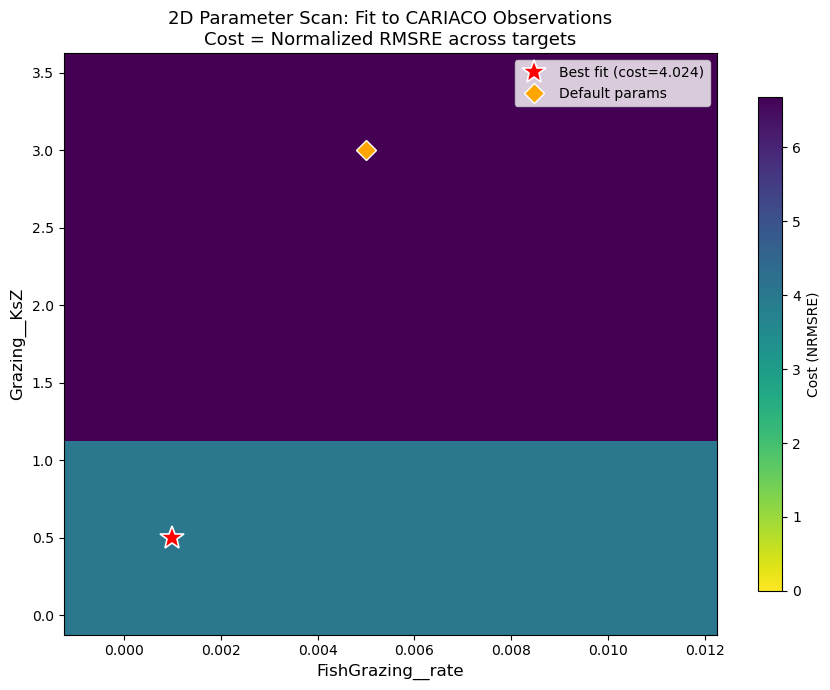

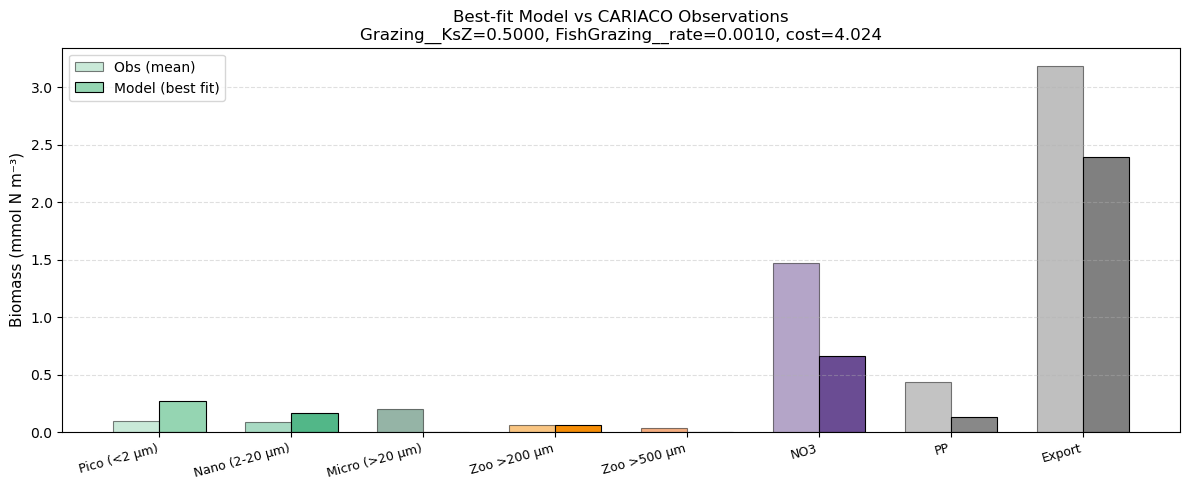

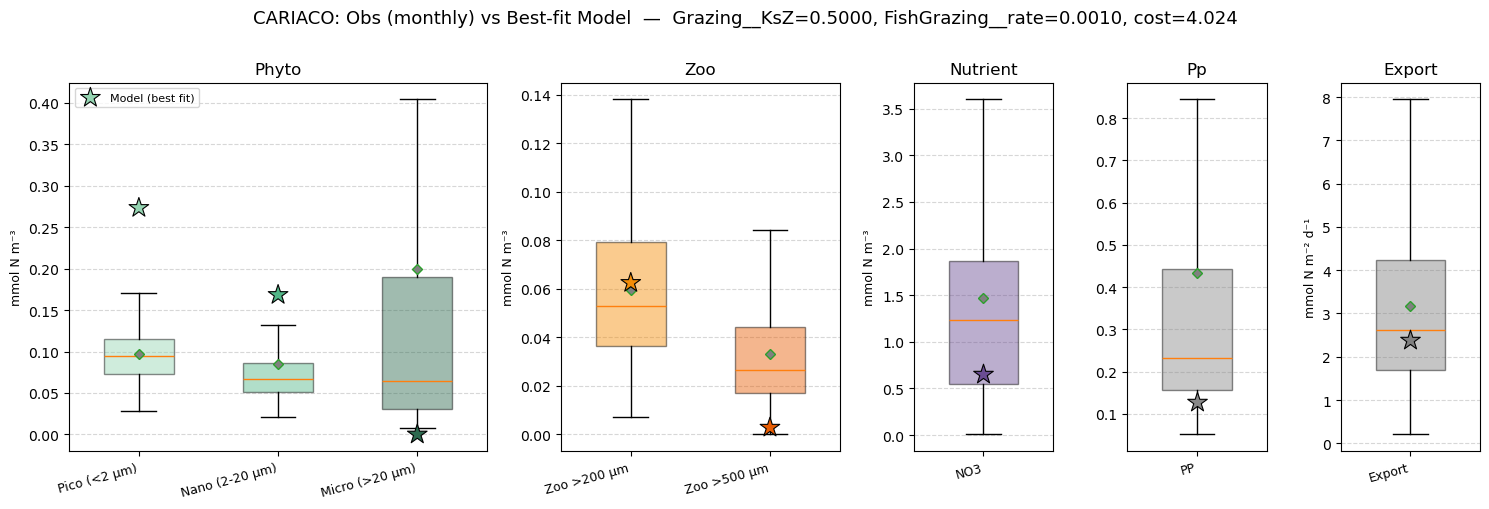


 BEST-FIT SUMMARY  |  Overall cost (NRMSRE): 4.0242
     Component  Obs_Mean  Model_BestFit   Ratio  Rel_Error_%
  Pico (<2 µm)   0.09698        0.27341 2.81929    181.92874
Nano (2-20 µm)   0.08512        0.16838 1.97822     97.82243
Micro (>20 µm)   0.19977        0.00000 0.00000   -100.00000
   Zoo >200 µm   0.05938        0.06253 1.05305      5.30537
   Zoo >500 µm   0.03302        0.00282 0.08539    -91.46068
           NO3   1.46705        0.65932 0.44942    -55.05802
            PP   0.43247        0.12734 0.29444    -70.55602
        Export   3.18267        2.39027 0.75103    -24.89729


In [6]:
import matplotlib.pyplot as plt
from parscan_plots import (
    plot_cost_heatmap,
    plot_model_vs_obs_bars,
    plot_model_vs_obs_boxplots,
    summarize_best_fit,
)

# Build default dict for heatmap marker
default = {
    'val1': get_default_from_setup(model_setup, p1_name),
    'val2': get_default_from_setup(model_setup, p2_name),
}

# Build title_info string for bar / boxplot titles
title_info = (f"{p1_name}={best['val1']:.4f}, "
              f"{p2_name}={best['val2']:.4f}, "
              f"cost={best['cost']:.3f}")

# 1. Cost heatmap
fig1 = plot_cost_heatmap(
    cost_grid=cost_grid,
    vals1=p1_values,
    vals2=p2_values,
    p1_label=p1_name,
    p2_label=p2_name,
    best=best,
    default=default,
)
plt.show()

# 2. Bar comparison
fig2 = plot_model_vs_obs_bars(
    model_vec=best['model_vec'],
    obs_vec=obs_vec,
    bin_definitions=bin_defs,
    title_info=title_info,
)
plt.show()

# 3. Boxplots with monthly obs variance
fig3 = plot_model_vs_obs_boxplots(
    model_vec=best['model_vec'],
    monthly_df=monthly_df,
    bin_definitions=bin_defs,
    title_info=title_info,
)
plt.show()

# 4. Numerical summary
summary = summarize_best_fit(
    model_vec=best['model_vec'],
    obs_vec=obs_vec,
    labels=labels,
    cost=best['cost'],
)